In [ ]:
!pip install deepxde  # already installed

In [ ]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

## Defining Burger Equation

In [4]:
def burgers_equation(x, u):
    du_t = dde.grad.jacobian(u, x, i=0, j=1)
    du_x = dde.grad.jacobian(u, x, i=0, j=0)
    du_xx = dde.grad.hessian(u, x, i=0, j=0)
    return du_t + u * du_x - (0.01/np.pi) * du_xx

### Defining Time Domain

In [ ]:
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

### Boundary && Initial Condition

In [6]:
def boundary(x, on_boundary):
    return on_boundary

bc = dde.DirichletBC(geomtime, lambda x: 0, boundary)


def initial_condition(x):
    return -np.sin(np.pi * x[:, 0:1])

ic = dde.IC(geomtime, initial_condition, lambda x, on_initial: on_initial)

### Build the Dataset

In [7]:
data = dde.data.TimePDE(geomtime, burgers_equation, [bc, ic], num_domain=4000, num_boundary=100, num_initial=400, num_test=10000)

### Defining Neural Network

In [8]:
net = dde.nn.FNN(
    layer_sizes=[2] + [64] * 3 + [1],
    activation="tanh",
    kernel_initializer="Glorot normal",
)

In [9]:
model = dde.Model(data, net)


model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=20000)

# Then fine-tune with smaller lr
model.compile("L-BFGS")
losshistory, train_state = model.train()


Compiling model...
'compile' took 0.242966 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7ae2fad94400>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ae2fad94400>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [9.26e-02, 3.91e-02, 5.70e-01]    [9.18e-02, 3.91e-02, 5.70e-01]    []  
1000      [3.99e-02, 6.00e-04, 5.34e-02]    [4.27e-02, 6.00e-04, 5.34e-02]    []  
2000      [3.96e-02, 2.16e-03, 4.06e-02]    [4.50e-02, 2.16e-03, 4.06e-02]    []  
3000      [2.46e-02, 1.03e-04, 3.41e-02]    [2.90e-02, 1.03e-04, 3.41e-02]    []  
4000      [1.24e-02, 1.75e-04, 1.14e-02]    [1.63e-02, 1.75e-04, 1.14e-02]    []  
5000      [

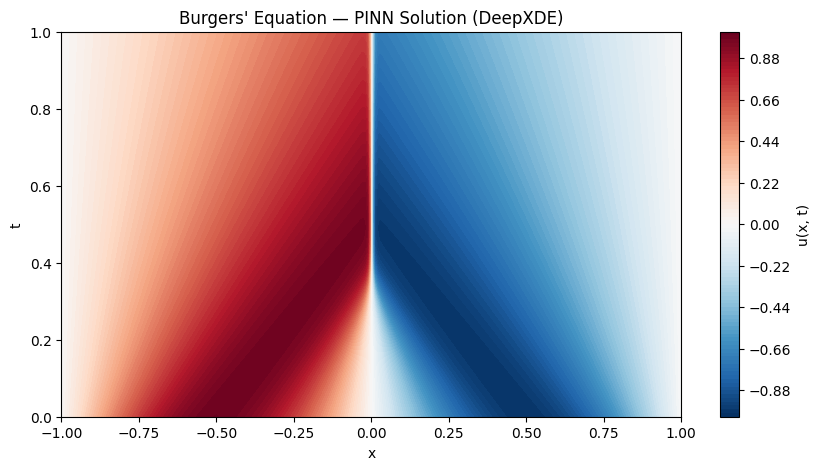

In [11]:
# ── 8. Visualize the Solution ──────────────────────────────────────
X = np.linspace(-1, 1, 256)
T = np.linspace(0, 1, 100)
XX, TT = np.meshgrid(X, T)

# Predict u(x,t) over the entire grid
XT = np.column_stack([XX.ravel(), TT.ravel()])
u_pred = model.predict(XT).reshape(100, 256)

plt.figure(figsize=(10, 5))
plt.contourf(XX, TT, u_pred, levels=100, cmap="RdBu_r")
plt.colorbar(label="u(x, t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Burgers' Equation — PINN Solution (DeepXDE)")
plt.show()